# Synthetic coronary masks for stenosis quantification validation

Generates two binary `.nrrd` segmentation masks (vessel = 1, background = 0) on a **100×100×100** grid with **1.0 mm** isotropic spacing:

| File | Description |
|------|-------------|
| `synthetic_healthy.nrrd` | Straight cylinder, constant radius **R = 10 mm** |
| `synthetic_stenosis.nrrd` | Same tube with a smooth cosine narrowing (**R → 5 mm** at the centre) |

Centreline: **(50, 50, Z)** in index space. Vessel extent: **Z = 10 … 90**.

Run all cells in order. Outputs are written next to this notebook.

## Mathematical expectations (reference)

For a circular cross-section with radius \(R\) (mm), area \(A = \pi R^2\):

| Quantity | Formula | Value (mm² or %) |
|----------|---------|------------------|
| **Max area** (healthy / reference) | \(\pi \times 10^2\) | **≈ 314.16** |
| **Min area** (stenosis neck, \(r = 5\)) | \(\pi \times 5^2\) | **≈ 78.54** |
| **Max % area stenosis** | \((1 - A_{\min}/A_{\max}) \times 100\) | **= 75%** |

The stenosis case uses a cosine profile on **Z ∈ [40, 60]** with minimum radius at **Z = 50**.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import nrrd

# ---------------------------------------------------------------------------
# Setup
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
OUTPUT_DIR = NOTEBOOK_DIR

SHAPE = (100, 100, 100)  # (Z, Y, X) — matches pipeline mask layout after VMTK load
SPACING_MM = (1.0, 1.0, 1.0)
CENTER_XY = (50, 50)
Z_START, Z_END = 10, 90
R_BASE = 10.0

Z_NARROW_LO, Z_NARROW_HI = 40, 60
Z_NARROW_MID = 50
R_MIN = 5.0

assert SHAPE == (100, 100, 100)
assert Z_NARROW_MID == (Z_NARROW_LO + Z_NARROW_HI) // 2

In [2]:
def radius_profile(z: np.ndarray) -> np.ndarray:
    """Radius (mm) along Z for the stenosis tube (cosine narrowing on [40, 60])."""
    r = np.full_like(z, R_BASE, dtype=float)
    in_narrow = (z >= Z_NARROW_LO) & (z <= Z_NARROW_HI)
    half_width = (Z_NARROW_HI - Z_NARROW_LO) / 2.0  # 10 mm
    t = (z[in_narrow] - Z_NARROW_MID) / half_width  # -1 … +1
    # r_min at centre (t=0), r_base at shoulders (t=±1)
    r[in_narrow] = R_MIN + (R_BASE - R_MIN) * (1.0 - np.cos(np.pi * t)) / 2.0
    return r


def build_tube_mask(radius_fn) -> np.ndarray:
    """
    Binary mask in (Z, Y, X) index order.
    Voxel is vessel if Z in [Z_START, Z_END] and sqrt((x-cx)^2 + (y-cy)^2) <= R(z).
    """
    nz, ny, nx = SHAPE
    cx, cy = CENTER_XY
    mask = np.zeros(SHAPE, dtype=np.uint8)

    z_idx = np.arange(nz, dtype=float)
    r_z = radius_fn(z_idx)

    y_idx, x_idx = np.mgrid[0:ny, 0:nx]
    dist_xy = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2)

    for z in range(nz):
        if z < Z_START or z > Z_END or r_z[z] <= 0:
            continue
        mask[z, dist_xy <= r_z[z]] = 1

    return mask


def nrrd_header() -> dict:
    """NRRD header with 1 mm isotropic space directions (VTK / pipeline compatible)."""
    return {
        "type": "uint8",
        "encoding": "gzip",
        "space": "left-posterior-superior",
        "space directions": [
            [SPACING_MM[0], 0.0, 0.0],
            [0.0, SPACING_MM[1], 0.0],
            [0.0, 0.0, SPACING_MM[2]],
        ],
        "space origin": (0.0, 0.0, 0.0),
        "kinds": ["domain", "domain", "domain"],
    }


def save_mask_nrrd(mask_zyx: np.ndarray, path: Path) -> None:
    """Write mask for VMTK: store array as (X, Y, Z) with matching header."""
    data_xyz = np.transpose(mask_zyx, (2, 1, 0))  # (nx, ny, nz)
    nrrd.write(str(path), data_xyz, header=nrrd_header())
    print(f"Saved {path.name}  shape(zyx)={mask_zyx.shape}  voxels={int(mask_zyx.sum())}")

In [3]:
# ---------------------------------------------------------------------------
# 1. Synthetic healthy tube
# ---------------------------------------------------------------------------
def healthy_radius(z: np.ndarray) -> np.ndarray:
    r = np.zeros_like(z, dtype=float)
    in_tube = (z >= Z_START) & (z <= Z_END)
    r[in_tube] = R_BASE
    return r


mask_healthy = build_tube_mask(healthy_radius)
path_healthy = OUTPUT_DIR / "synthetic_healthy.nrrd"
save_mask_nrrd(mask_healthy, path_healthy)

Saved synthetic_healthy.nrrd  shape(zyx)=(100, 100, 100)  voxels=25677


In [4]:
# ---------------------------------------------------------------------------
# 2. Synthetic stenosis tube
# ---------------------------------------------------------------------------
def stenosis_radius(z: np.ndarray) -> np.ndarray:
    r = np.zeros_like(z, dtype=float)
    in_tube = (z >= Z_START) & (z <= Z_END)
    r[in_tube] = radius_profile(z[in_tube])
    return r


mask_stenosis = build_tube_mask(stenosis_radius)
path_stenosis = OUTPUT_DIR / "synthetic_stenosis.nrrd"
save_mask_nrrd(mask_stenosis, path_stenosis)

# Sanity: radius at the stenosis centre and shoulders
z_test = np.array([40.0, 50.0, 60.0])
print("Radius profile (mm) at Z =", z_test, "→", np.round(radius_profile(z_test), 4))

Saved synthetic_stenosis.nrrd  shape(zyx)=(100, 100, 100)  voxels=23105
Radius profile (mm) at Z = [40. 50. 60.] → [10.  5. 10.]


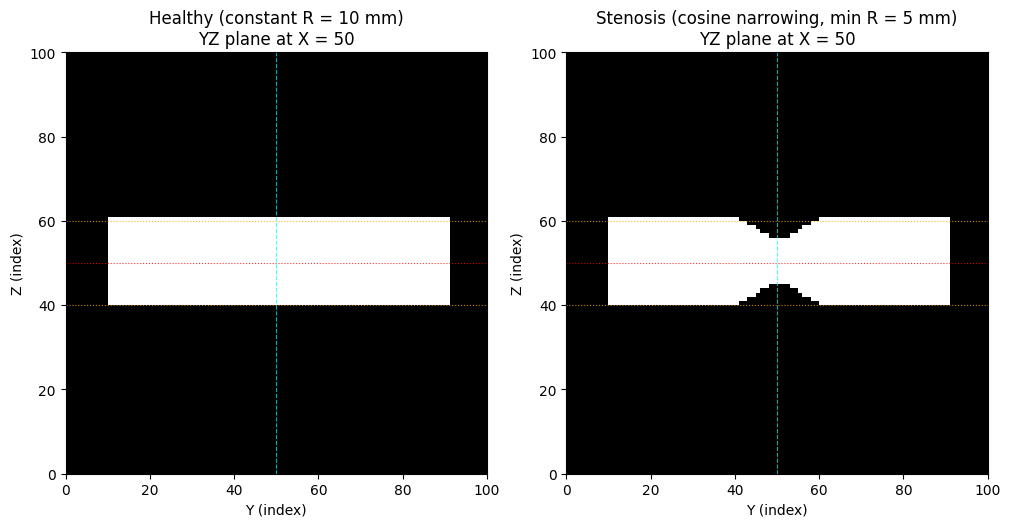

Reference areas: A_max ≈ 314.16 mm², A_min ≈ 78.54 mm², max %AS = 75%


In [5]:
# ---------------------------------------------------------------------------
# 3. Validation — central YZ slice (fixed X = centre)
# ---------------------------------------------------------------------------
cx, _ = CENTER_XY
slice_healthy = mask_healthy[:, :, cx]   # (Z, Y)
slice_stenosis = mask_stenosis[:, :, cx]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

for ax, slc, title in zip(
    axes,
    [slice_healthy, slice_stenosis],
    ["Healthy (constant R = 10 mm)", "Stenosis (cosine narrowing, min R = 5 mm)"],
):
    ax.imshow(
        slc.T,
        origin="lower",
        cmap="gray",
        aspect="equal",
        extent=[0, SHAPE[1], 0, SHAPE[0]],
    )
    ax.axvline(CENTER_XY[1], color="cyan", ls="--", lw=0.8, alpha=0.7)
    ax.axhline(Z_NARROW_LO, color="orange", ls=":", lw=0.8, alpha=0.8)
    ax.axhline(Z_NARROW_HI, color="orange", ls=":", lw=0.8, alpha=0.8)
    ax.axhline(Z_NARROW_MID, color="red", ls=":", lw=0.8, alpha=0.8)
    ax.set_xlabel("Y (index)")
    ax.set_ylabel("Z (index)")
    ax.set_title(f"{title}\nYZ plane at X = {cx}")

plt.show()

print(
    "Reference areas: A_max ≈ {:.2f} mm², A_min ≈ {:.2f} mm², max %AS = {:.0f}%".format(
        np.pi * R_BASE**2,
        np.pi * R_MIN**2,
        (1.0 - (R_MIN / R_BASE) ** 2) * 100.0,
    )
)